# Multi-Output Earthquake Prediction

<img src='https://th-thumbnailer.cdn-si-edu.com/hKjrxzzsFj2tyyTNYXT7MFu_LRM=/fit-in/1600x0/filters:focal(527x392:528x393)/https://tf-cmsv2-smithsonianmag-media.s3.amazonaws.com/filer/ac/13/ac13f925-b152-46f9-9eb3-7fa475fc3e81/earthquakes.jpg'>

Bu çalışmanın amacı, çoklu regresyon yaklaşımı kullanarak deprem Magnitude ve Depth değerlerini aynı anda tahmin edebilen bir model geliştirmektir.

The aim of this study is to develop a model that can simultaneously predict earthquake magnitude and depth using a multiple regression approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [2]:
df=pd.read_csv('database.csv') 

In [3]:
#EDA

In [4]:
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [6]:
df.isnull().sum()

Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64

In [7]:
df = df.dropna(axis=1, how='any')

In [8]:
df.isnull().sum()

Date                0
Time                0
Latitude            0
Longitude           0
Type                0
Depth               0
Magnitude           0
ID                  0
Source              0
Location Source     0
Magnitude Source    0
Status              0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              23412 non-null  object 
 1   Time              23412 non-null  object 
 2   Latitude          23412 non-null  float64
 3   Longitude         23412 non-null  float64
 4   Type              23412 non-null  object 
 5   Depth             23412 non-null  float64
 6   Magnitude         23412 non-null  float64
 7   ID                23412 non-null  object 
 8   Source            23412 non-null  object 
 9   Location Source   23412 non-null  object 
 10  Magnitude Source  23412 non-null  object 
 11  Status            23412 non-null  object 
dtypes: float64(4), object(8)
memory usage: 2.1+ MB


In [10]:
df.head(10)

,Date,Time,Latitude,Longitude,Type,Depth,Magnitude,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,6.0,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,5.8,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,6.2,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,5.8,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,5.8,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
5,01/10/1965,13:36:32,-13.405,166.629,Earthquake,35.0,6.7,ISCGEM860922,ISCGEM,ISCGEM,ISCGEM,Automatic
6,01/12/1965,13:32:25,27.357,87.867,Earthquake,20.0,5.9,ISCGEM861007,ISCGEM,ISCGEM,ISCGEM,Automatic
7,01/15/1965,23:17:42,-13.309,166.212,Earthquake,35.0,6.0,ISCGEM861111,ISCGEM,ISCGEM,ISCGEM,Automatic
8,01/16/1965,11:32:37,-56.452,-27.043,Earthquake,95.0,6.0,ISCGEMSUP861125,ISCGEMSUP,ISCGEM,ISCGEM,Automatic
9,01/17/1965,10:43:17,-24.563,178.487,Earthquake,565.0,5.8,ISCGEM861148,ISCGEM,ISCGEM,ISCGEM,Automatic


In [11]:
#Feature Engineering

In [12]:
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce', utc=True)

# Eğer Date, Time zaten birleşik biçimde ise sadece Date üzerinden dönüştür:
df.loc[df['Datetime'].isna(), 'Datetime'] = pd.to_datetime(df.loc[df['Datetime'].isna(), 'Date'], errors='coerce', utc=True)

In [13]:
df.isnull().sum()

Date                0
Time                0
Latitude            0
Longitude           0
Type                0
Depth               0
Magnitude           0
ID                  0
Source              0
Location Source     0
Magnitude Source    0
Status              0
Datetime            0
dtype: int64

In [14]:
#pip install basemap

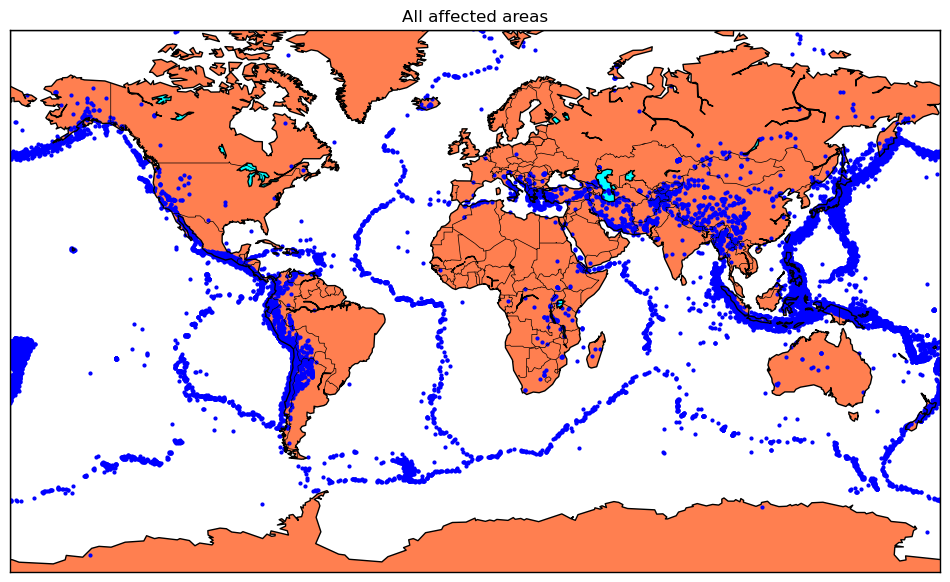

In [15]:
from mpl_toolkits.basemap import Basemap

m = Basemap(projection='mill',llcrnrlat=-80,urcrnrlat=80, llcrnrlon=-180,urcrnrlon=180,lat_ts=20,resolution='c')

longitudes = df["Longitude"].tolist()
latitudes = df["Latitude"].tolist()
#m = Basemap(width=12000000,height=9000000,projection='lcc',
            #resolution=None,lat_1=80.,lat_2=55,lat_0=80,lon_0=-107.)
x,y = m(longitudes,latitudes)

fig = plt.figure(figsize=(12,10))
plt.title("All affected areas")
m.plot(x, y, "o", markersize = 2, color = 'blue')
m.drawcoastlines()
m.fillcontinents(color='coral',lake_color='aqua')
m.drawmapboundary()
m.drawcountries()
plt.show()

In [16]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Date              23412 non-null  object             
 1   Time              23412 non-null  object             
 2   Latitude          23412 non-null  float64            
 3   Longitude         23412 non-null  float64            
 4   Type              23412 non-null  object             
 5   Depth             23412 non-null  float64            
 6   Magnitude         23412 non-null  float64            
 7   ID                23412 non-null  object             
 8   Source            23412 non-null  object             
 9   Location Source   23412 non-null  object             
 10  Magnitude Source  23412 non-null  object             
 11  Status            23412 non-null  object             
 12  Datetime          23412 non-null  datetime64[ns, UTC]
 13  Y

In [18]:
df = df.drop(['Date', 'Time', 'ID', 'Datetime', 'Type','Status', 'Source','Location Source','Magnitude Source'], axis=1)

In [19]:
df.head()

,Latitude,Longitude,Depth,Magnitude,Year,Month,Day,Hour,Minute
0,19.246,145.616,131.6,6.0,1965,1,2,13,44
1,1.863,127.352,80.0,5.8,1965,1,4,11,29
2,-20.579,-173.972,20.0,6.2,1965,1,5,18,5
3,-59.076,-23.557,15.0,5.8,1965,1,8,18,49
4,11.938,126.427,15.0,5.8,1965,1,9,13,32


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   23412 non-null  float64
 1   Longitude  23412 non-null  float64
 2   Depth      23412 non-null  float64
 3   Magnitude  23412 non-null  float64
 4   Year       23412 non-null  int32  
 5   Month      23412 non-null  int32  
 6   Day        23412 non-null  int32  
 7   Hour       23412 non-null  int32  
 8   Minute     23412 non-null  int32  
dtypes: float64(4), int32(5)
memory usage: 1.2 MB


In [21]:
df.head()

,Latitude,Longitude,Depth,Magnitude,Year,Month,Day,Hour,Minute
0,19.246,145.616,131.6,6.0,1965,1,2,13,44
1,1.863,127.352,80.0,5.8,1965,1,4,11,29
2,-20.579,-173.972,20.0,6.2,1965,1,5,18,5
3,-59.076,-23.557,15.0,5.8,1965,1,8,18,49
4,11.938,126.427,15.0,5.8,1965,1,9,13,32


In [22]:
x = df[['Latitude', 'Longitude', 'Year', 'Month', 'Day', 'Hour', 'Minute']]
y = df[['Magnitude', 'Depth']]

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=.20,random_state=42)

In [41]:
def algo_test(x, y):
    from sklearn.multioutput import MultiOutputRegressor
    from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.tree import ExtraTreeRegressor, DecisionTreeRegressor
    from xgboost import XGBRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import numpy as np
    import pandas as pd

    # Multi-output desteklemeyenler için wrapper
    GBR = MultiOutputRegressor(GradientBoostingRegressor())
    
    # Native multi-output destekleyenler
    ETR = ExtraTreeRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()
    
    algos = [ETR, GBR, dt, xgb]
    algo_names = ['Gradient Boosting', 'KNeighborsRegressor', 'Decision Tree', 'XGBRegressor']
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p, multioutput='variance_weighted'))
        rmse.append(np.sqrt(mean_squared_error(y_test, p)))
        mae.append(mean_absolute_error(y_test, p))
    
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae
    
    rtable = result.sort_values('R_Squared', ascending=False)
    return rtable

In [42]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.806855,39.159450,14.556013
Decision Tree,0.732982,46.043179,13.301958
KNeighborsRegressor,0.599333,56.400957,21.842952
Gradient Boosting,0.465436,65.147051,19.514471


In [43]:
model = MultiOutputRegressor(XGBRegressor())
model.fit(x_train, y_train)
tahmin = model.predict(x_test)

In [44]:
residuals = y_test - tahmin

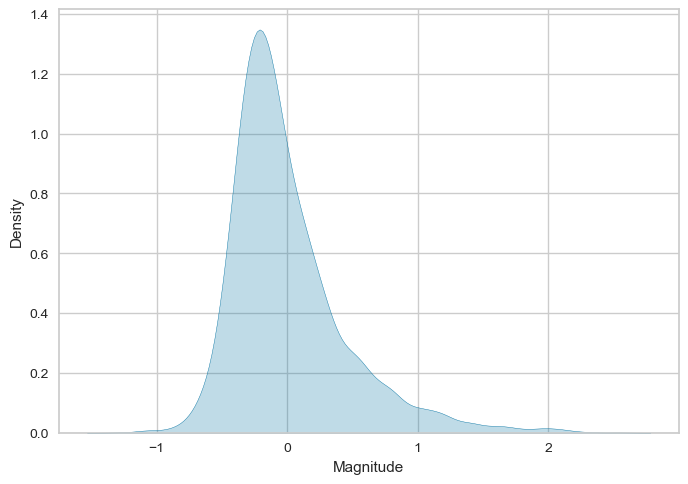

In [46]:
sns.kdeplot(x=residuals['Magnitude'], fill=True); 

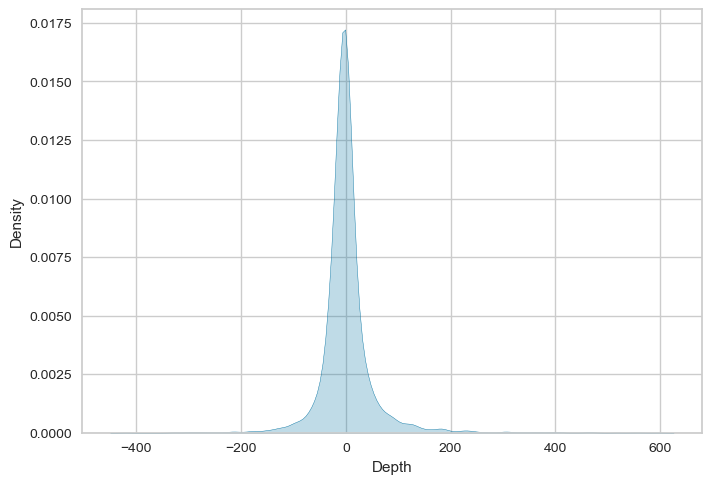

In [47]:
sns.kdeplot(x=residuals['Depth'], fill=True); 

In [49]:
#with deep learning

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

In [60]:
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=x_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(2))  # son katmanda activation yok! veya activation='linear'

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

In [61]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [62]:
history = model.fit(x_train, y_train,validation_data=(x_test, y_test),epochs=50, batch_size=64,callbacks=[early_stop],verbose=1)

Epoch 1/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8456.8184 - mae: 32.5072 - val_loss: 7881.8296 - val_mae: 36.0868
Epoch 2/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7288.6865 - mae: 34.8696 - val_loss: 7805.6196 - val_mae: 35.7804
Epoch 3/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7234.2622 - mae: 34.8280 - val_loss: 7739.4258 - val_mae: 36.0042
Epoch 4/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7185.9126 - mae: 34.8008 - val_loss: 7682.0005 - val_mae: 36.2087
Epoch 5/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7141.6338 - mae: 34.9267 - val_loss: 7642.1851 - val_mae: 36.2896
Epoch 6/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7107.1851 - mae: 34.8996 - val_loss: 7604.6543 - val_mae: 35.9969
Epoch 7/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7079.5625 - mae: 34.7071 - val_loss: 7581.0088 - val_mae: 35.7877
Epoch 8/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7054.2134 - mae: 34.5627 - val_loss: 7548.4902 - val_mae: 

In [63]:
# Tahmin
tahmin = model.predict(x_test)

147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [67]:
print("R2:", r2_score(y_test, tahmin, multioutput='variance_weighted'))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tahmin)))

R2: 0.14552825689315796
RMSE: 82.36520711896499


Yapılan analizler sonucunda, Magnitude ve Depth tahmini için hem makine öğrenmesi hem de derin öğrenme modelleri uygulanmıştır. En yüksek performans XGBRegressor modeli ile elde edilmiş (R²: 0.81, RMSE: 39.16), bunu sırasıyla Decision Tree Regressor (R²: 0.73) ve KNeighborsRegressor (R²: 0.60) izlemiştir. Basit derin öğrenme modeli ise düşük performans göstermiştir (R²: 0.15, RMSE: 82.37).

As a result of the analyses, both machine learning and deep learning models were applied for Magnitude and Depth estimation. The highest performance was obtained with the XGBRegressor model (R²: 0.81, RMSE: 39.16), followed by Decision Tree Regressor (R²: 0.73) and KNeighborsRegressor (R²: 0.60). The simple deep learning model showed low performance (R²: 0.15, RMSE: 82.37).


In [ ]:
best_model = MultiOutputRegressor(XGBRegressor())
model.fit(x_train, y_train)
tahmin = model.predict(x_test)

In [78]:
best_model = MultiOutputRegressor(XGBRegressor())
best_model.fit(x, y)

#2. Feature listesini al
features = list(x.columns)

# 3. Modeli kaydet (joblib + pkl)
import joblib, pickle

# joblib 
joblib.dump(best_model, 'earthquake_pred.joblib')

# bundle (model + feature)
with open('earthquake_pred.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'features': features
    }, f)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'